# 第四章 构建完整的GPT模型

在前面的章节，我们呢实现了文本的预处理，和注意力机制的实现。现在我们将把这些组件组合在一起，构建一个完整的GPT模型。


In [3]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.8
torch version: 2.11.0
tiktoken version: 0.12.0


## 4.1 实现LLM的架构

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="400px">

前几张已经学习了分词，嵌入，注意力机制等组件，现在我们将把这些组件组合在一起，构建一个完整的GPT模型。

通过以下python字典来配置XIN_GPT模型的参数：

In [12]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 词典大小
    "context_length": 1024, # 上下文长度
    "emb_dim": 768,         # 嵌入维度
    "n_heads": 12,          # 注意力头的数量
    "n_layers": 12,         # 层数
    "drop_rate": 0.1,       # 丢弃概率
    "qkv_bias": False       # 是否在查询、键和值的线性层中使用偏置
}

上述代码各个参数的含义是：
- `vocab_size`: 词典大小，表示模型可以处理的不同词汇
- `context_length`: 上下文长度，表示模型可以处理的最大输入长度
- `emb_dim`: 嵌入维度，表示每个单词的向量维度
- `n_heads`: 注意力头的数量，表示模型可以同时处理多少个单词
- `n_layers`: 层数，表示模型有多少个层
- `drop_rate`: 丢弃概率，表示模型在训练过程中随机丢弃一些神经元的概率，以防止过拟合
- `qkv_bias`: 是否在查询、键和值的线性层中使用偏置，表示模型是否在计算查询、键和值时使用偏置项

下图为要实现的各个部分
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

In [5]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # 使用一个占位符来表示Transformer块
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # 使用一个占位符来表示最终的LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 这个块没有实际的实现，只是一个占位符。

    def forward(self, x):
        # 这个块没有实际的实现，只是一个占位符，直接返回输入。
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # 这个块没有实际的实现，只是一个占位符。

    def forward(self, x):
        # 这个块没有实际的实现，只是一个占位符，直接返回输入。
        return x

In [10]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)
# 这段代码使用了`tiktoken`库来获取GPT-2的编码器，并将两个文本字符串编码成整数序列。然后，这些整数序列被转换成PyTorch张量，并堆叠成一个批次（batch）。最后，打印出这个批次的内容。

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [13]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)
# 在DummyGPTModel中，token序列中的每个整数都被映射到一个768维的嵌入向量。然后，这些嵌入向量被加上位置嵌入，并通过一个占位符Transformer块进行处理。最后，经过一个占位符LayerNorm和一个线性层，输出的logits具有形状[2, 4, 50257]，其中2是批次大小，4是序列长度，50257是词汇表大小。

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 使用层归一化对激活值进行标准化
归一化的核心思想是将数据转换为具有特定统计属性的形式，例如零均值和单位方差。简单来说就是把神经网络的输出调整为均值为0，方差为1。在现代的transformer架构中层归一化常用于多头注意力模块的前后以及最终输出层之前。

与传统神经网络的归一化方法（Batch Normalization)）不同，层归一化（Layer Normalization)是对输入向量进行归一化的。层归一化的核心思想是计算输入向量的均值和方差，并使用这两个值来缩放和平移输入向量。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

In [19]:
# 上图展示了对一个五维的输入向量进行归一化的过程。
torch.manual_seed(123)
# 创建两个批次，每个批次包含一个五维的输入向量
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


上面的代码中我们简单的实现了一个线性层和一个ReLU激活函数，并使用随机数填充了输入向量。然后，将输入向量传入线性层，并使用ReLU激活函数进行非线性映射。最后，将输出向量打印出来。

In [20]:
# # 输出归一化之前的均值和方差
# print("输入的均值和方差")
# print("Mean:", batch_example.mean(dim=-1,keepdim=True))
# print("Var:", batch_example.var(dim=-1,keepdim=True))
print("归一化前的输出:")
print("Mean:", out.mean(dim=-1,keepdim=True))
print("Var:", out.var(dim=-1,keepdim=True))

输入的均值和方差
Mean: tensor([[-0.3596],
        [-0.2606]])
Var: tensor([[0.2518],
        [0.3342]])
归一化前的输出:
Mean: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Var: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [22]:
# 禁用科学计数法
torch.set_printoptions(sci_mode=False)

mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
out_norm = (out - mean) / torch.sqrt(var)
print("归一化后的输出:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

归一化后的输出:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


把上述的层归一化封装成一个类：

In [26]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5 # 防止分母为0
        # 缩放参数和偏移参数（可学习）
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [27]:
ln = LayerNorm(6)
out_norm = ln(out)
print(out_norm)
print("归一化后的输出:")
print("Mean:", out_norm.mean(dim=-1,keepdim=True))
print("Var:", out_norm.var(dim=-1,keepdim=True))


tensor([[ 0.6157,  1.4123, -0.8717,  0.5871, -0.8717, -0.8717],
        [-0.0189,  0.1121, -1.0875,  1.5171,  0.5647, -1.0875]],
       grad_fn=<AddBackward0>)
归一化后的输出:
Mean: tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Var: tensor([[0.9996],
        [0.9997]], grad_fn=<VarBackward0>)


# 4.3 实现带有激活函数的前馈网络
- 在本节中，我们实现一个小型神经网络子模块，用作 LLM 中转换器块的一部分
- 我们从激活函数开始
- 在深度学习中，ReLU（整流线性单元）激活函数因其简单性和有效性而在各种神经网络架构中得到广泛使用
- 在 LLM 中，除了传统 ReLU 之外还使用了各种其他类型的激活函数；两个值得注意的例子是 GELU（高斯误差线性单元t) 和 SwiGLU（Swish-Gated Linear Unit）
- GELU 和 SwiGLU 是更复杂、更平滑的激活函数，分别结合了高斯和 sigmoid 门控线性单元，为深度学习模型提供了更好的性能，这与 ReLU 更简单的分段线性函数不同

In [29]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

简单绘制一下gelu和relu

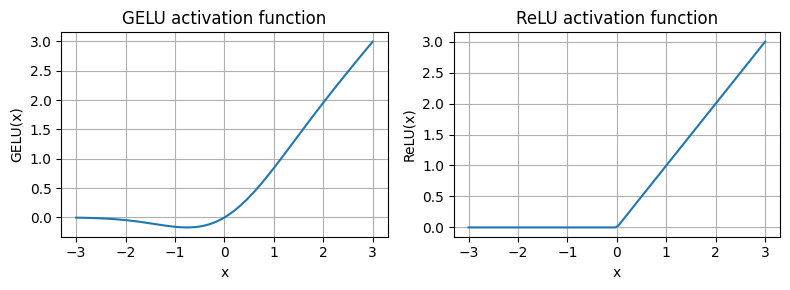

In [30]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
# 接下来会实现一个小型的神经网络模块，稍后会用在transformer模块里

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 定义一个包含两个线性层和gelu激活函数的序列
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [32]:
print(GPT_CONFIG_124M["emb_dim"])

768


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="400px">

In [33]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## 4.4 添加快捷连接（残差连接）
- 接下来，我们来谈谈快捷连接背后的概念，也称为跳过或残差连接
- 最初，快捷连接是在计算机视觉的深度网络（残差网络）中提出的，以减轻梯度消失问题
- 快捷连接为梯度流过网络创建更短的路径
- 这是通过将一层的输出添加到后面一层的输出来实现的，通常会跳过一层或多层
- 用一个小示例网络来说明这个想法：
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123" width="400px">

In [34]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # 计算层输出
            layer_output = layer(x)
            # 如果使用快捷连接，则将层输出与输入相加
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    # 基于output和target计算损失
    loss = nn.MSELoss()
    loss = loss(output, target)

    # 计算梯度
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # 打印参数的梯度
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [35]:
# 首先打印没有残差的
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


In [36]:
# 开启快捷连接
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


快捷连接的主要优点是它可以帮助模型避免梯度消失，从而提高模型的训练效率和性能
- 快捷连接的一个主要缺点是它可能会使模型更复杂，并增加训练所需的计算量
- 在实际应用中，根据模型的大小和复杂度，以及可用的计算资源，可能会选择不同的快捷连接策略

## 完成transformer模块，连接注意力层和线性层
- 在本节中，我们将实现一个Transformer模块，该模块将注意力层和线性层连接起来
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="400px">

In [38]:
from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

- 假设我们有 2 个输入样本，每个样本有 4 个 token，其中每个 token 是一个 768 维的嵌入向量；然后这个转换器块应用自注意力，然后是线性层，以产生类似大小的输出
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/14.webp?1" width="400px">

In [39]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("输入形状:", x.shape)
print("输出形状:", output.shape)

输入形状: torch.Size([2, 4, 768])
输出形状: torch.Size([2, 4, 768])


## 4.6实现GPT模型

本章开头的架构中，没有具体的实现。我们把架构中的模块改成本章后几个小节的实现。


In [41]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [42]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3612,  0.4223, -0.0709,  ...,  0.3479,  0.4655, -0.2833],
         [-0.1785, -0.5656, -0.9477,  ...,  0.0476,  0.5173, -0.3160],
         [ 0.7118,  0.0335,  0.1078,  ...,  0.1020, -0.4331, -0.2547],
         [-1.0068,  0.3420, -0.1191,  ...,  0.7193,  0.4018,  0.0532]],

        [[-0.2562,  0.0899,  0.0337,  ...,  0.2659,  0.4448, -0.6800],
         [ 0.1230,  0.3651, -0.2071,  ...,  0.7704,  0.2702,  0.2250],
         [ 1.0555,  1.0312, -0.2797,  ...,  0.6934,  0.3201, -0.3172],
         [-0.1559,  0.3922,  0.3286,  ...,  1.2627, -0.1862,  0.0391]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.7生成文本
- 现在我们已经实现了一个完整的GPT模型，我们可以使用它来生成文本
- 文本生成的核心思想是基于给定的输入文本，模型预测下一个最可能的单词，然后将这个单词添加到输入文本中，重复这个过程，直到生成所需长度的文本
- 下面是一个简单的文本生成示例
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="600px">

In [43]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [53]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [54]:
# model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [55]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
